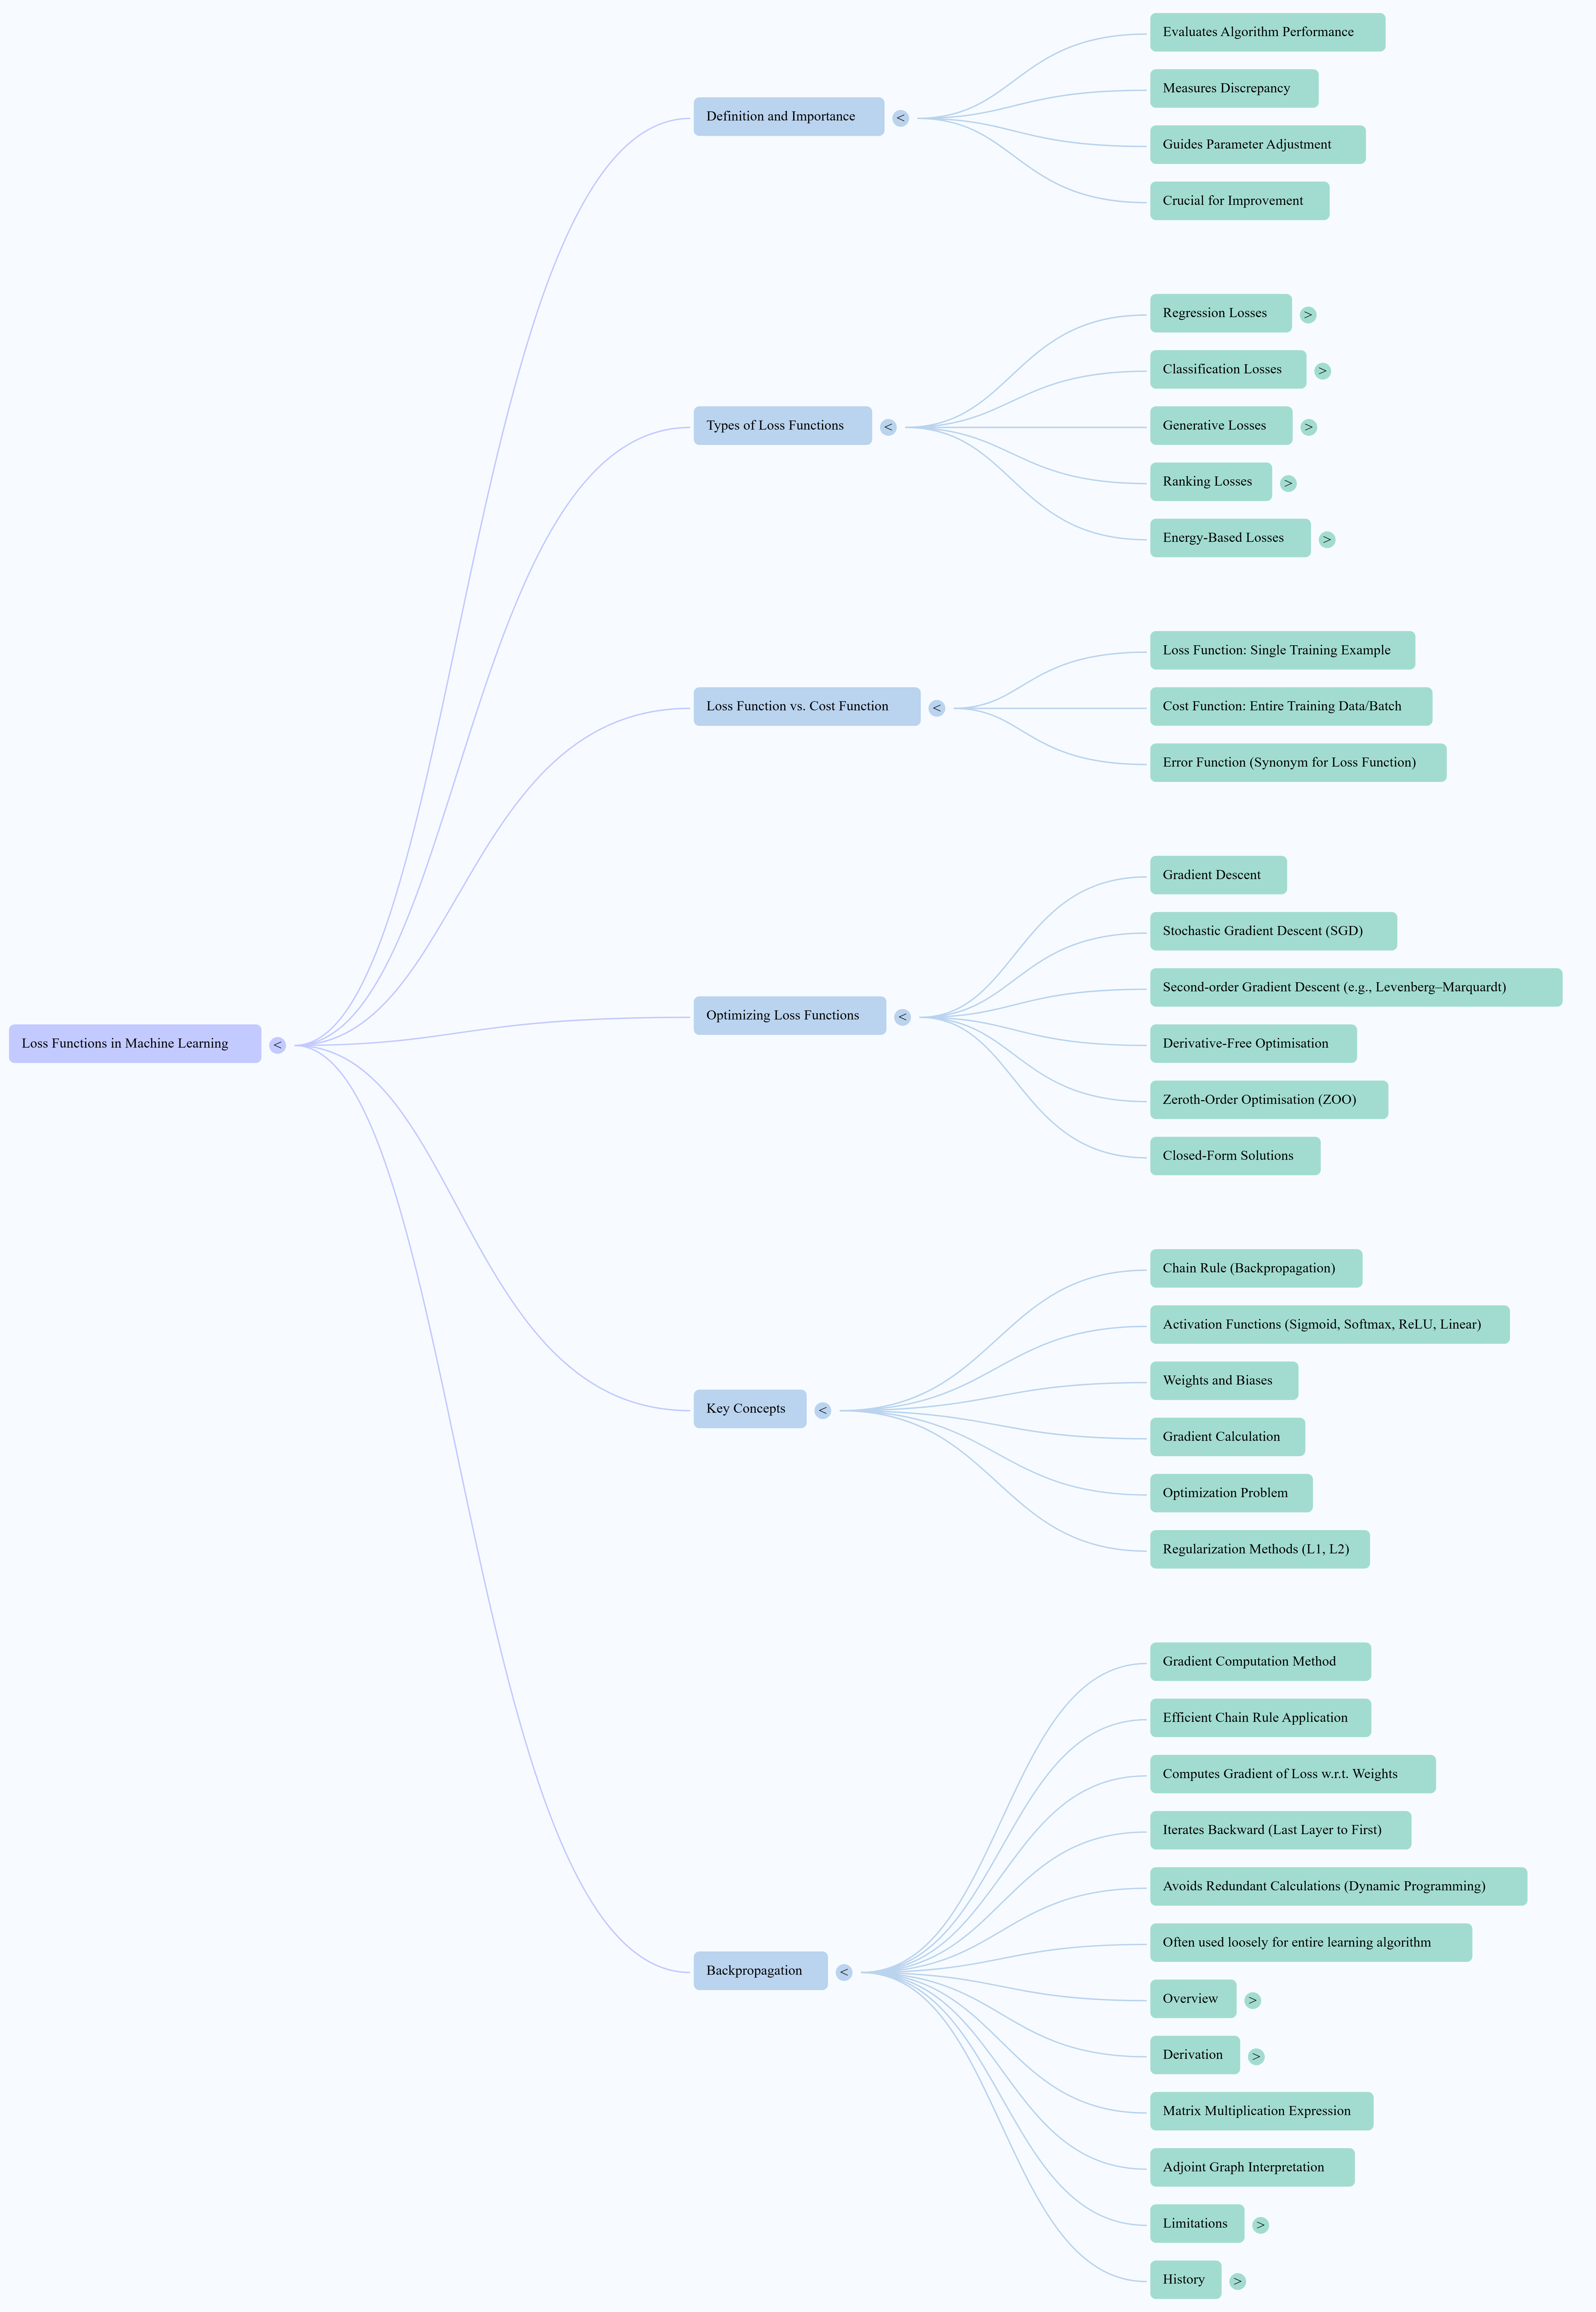

Great! Let’s dive deeper into **loss functions in deep learning**, their types, when to use each one, and the **advantages/disadvantages** of each.

---

## 🧠 What is a Loss Function (In Detail)?

A **loss function** is a mathematical expression that **quantifies the difference** between the model’s prediction and the actual output (ground truth). It is the core signal used to **train neural networks**.

The goal of training a model is to **minimize the loss**.

---

## 🔢 Types of Loss Functions with Details

### 1. **Regression Loss Functions**

Used when the target is a **continuous value** (e.g., house prices, temperature).

#### a. **Mean Squared Error (MSE)**

**Formula:**

$$
\text{MSE} = \frac{1}{n} \sum_{i=1}^{n}(y_i - \hat{y}_i)^2
$$

**Use When:**

* You want to penalize **large errors** more strongly.
* Most commonly used for standard regression tasks.

**Advantages:**

* Smooth gradient (helps with optimization).
* Emphasizes larger errors, useful when large mistakes are more costly.

**Disadvantages:**

* **Sensitive to outliers** (since errors are squared).

---

#### b. **Mean Absolute Error (MAE)**

**Formula:**

$$
\text{MAE} = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|
$$

**Use When:**

* You want to treat all errors **equally**.
* Outliers should not influence the model much.

**Advantages:**

* Robust to outliers.

**Disadvantages:**

* Gradient is not smooth at zero, which can slow training.

---

#### c. **Huber Loss**

**Combines MSE and MAE**: behaves like MSE near zero and MAE far from zero.

**Use When:**

* You want to be robust to outliers but still care about small errors.

**Advantages:**

* Good balance between MSE and MAE.
* Robust and differentiable.

**Disadvantages:**

* You need to set a hyperparameter delta (threshold between MAE and MSE behavior).

---

### 2. **Classification Loss Functions**

#### a. **Binary Cross-Entropy (Log Loss)**

**Formula:**

$$
\text{BCE} = - \frac{1}{n} \sum_{i=1}^{n} \left[ y_i \log(\hat{y}_i) + (1 - y_i) \log(1 - \hat{y}_i) \right]
$$

**Use When:**

* **Binary classification** tasks (e.g., spam detection, tumor vs. no tumor).

**Advantages:**

* Probabilistic interpretation.
* Strong theoretical foundation.

**Disadvantages:**

* Sensitive to imbalanced datasets unless weighted.

---

#### b. **Categorical Cross-Entropy**

**Formula:**

$$
\text{CCE} = - \sum_{i=1}^{C} y_i \log(\hat{y}_i)
$$

**Use When:**

* **Multi-class classification** with **one-hot labels**.
* Example: image classification with labels like "cat", "dog", "car".

**Advantages:**

* Works well with softmax output.
* Probabilistic, easy to interpret.

**Disadvantages:**

* Doesn't work directly with integer labels (use SparseCCE).

---

#### c. **Sparse Categorical Cross-Entropy**

Same as above but works with **integer labels** instead of one-hot vectors.

---

#### d. **Focal Loss**

Improves Cross-Entropy by focusing more on **hard misclassified examples**.

**Use When:**

* You have **class imbalance** (e.g., object detection).

**Advantages:**

* Helps model focus on underrepresented classes.

**Disadvantages:**

* Additional hyperparameter tuning (focusing factor).

---

### 3. **Losses for Special Cases**

#### a. **Hinge Loss**

Used with SVMs and classification with margin-based approaches.

#### b. **Contrastive Loss / Triplet Loss**

Used in **metric learning**, e.g., face verification, similarity matching.

**Contrastive Loss:**

* Minimizes distance between similar pairs, maximizes for dissimilar.

**Triplet Loss:**

* Uses anchor, positive, and negative samples to learn embedding distances.

#### c. **Dice Loss / IoU Loss**

Used in **image segmentation** (medical, satellite images).

---

## 🧰 When to Use Which?

| Task Type                  | Suggested Loss Function        | Notes                           |
| -------------------------- | ------------------------------ | ------------------------------- |
| Regression                 | MSE, MAE, Huber                | Huber for robust training       |
| Binary Classification      | Binary Cross-Entropy           | Use sigmoid activation          |
| Multi-class Classification | Categorical Cross-Entropy      | Use softmax activation          |
| Imbalanced Classification  | Focal Loss                     | Add class weights or focal loss |
| Image Segmentation         | Dice Loss, IoU Loss            | Works with masks                |
| Face/Speaker Recognition   | Triplet Loss, Contrastive Loss | Embedding-based learning        |

---

## ✅ Summary Table: Pros and Cons

| Loss Function      | Pros                                   | Cons                            |
| ------------------ | -------------------------------------- | ------------------------------- |
| **MSE**            | Smooth gradients, penalizes big errors | Sensitive to outliers           |
| **MAE**            | Robust to outliers                     | Non-smooth gradients            |
| **Huber**          | Balanced approach                      | Needs a hyperparameter          |
| **Binary CE**      | Probabilistic, standard for binary     | Sensitive to imbalance          |
| **Categorical CE** | Natural for softmax                    | Needs one-hot labels            |
| **Focal Loss**     | Handles imbalance                      | Extra parameters, more complex  |
| **Dice Loss**      | Excellent for segmentation             | May not generalize beyond masks |
| **Triplet Loss**   | Good for similarity learning           | Needs carefully chosen samples  |

---



In [1]:
import tensorflow as tf
import numpy as np

# Dummy regression data
X = np.random.rand(100, 1)
y = 3 * X + 2 + np.random.randn(100, 1) * 0.1  # Linear relation + noise

# Model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1, input_shape=(1,))
])

# Compile with MSE
model.compile(optimizer='adam', loss='mse')

# Train
model.fit(X, y, epochs=10)


Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 9.9485   
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 9.6570 
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 9.5856 
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 9.6694 
Epoch 5/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 9.4075 
Epoch 6/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 9.6067 
Epoch 7/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 9.5028 
Epoch 8/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 9.8012 
Epoch 9/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 9.4275 
Epoch 10/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 9.6223  
